# WiDS Datathon 2020 — Meeting 6: Fairness Analysis

Fairness audit of the **CatBoost** ICU mortality predictor
(Meeting 2 best model · validation ROC-AUC = 0.893 · 12 % capacity cutoff).

**Protected attributes examined:** gender · ethnicity · age group

**Fairness criteria (from Fair-ML lecture):**
| Criterion | Definition |
|-----------|------------|
| **Demographic parity** | Equal flagging rate across groups |
| **Equal odds** | Equal sensitivity *and* specificity across groups |
| **Predictive-rate parity / calibration** | Equal PPV / NPV and calibration curves across groups |

**Outline:**
1. Data-level fairness — group distributions, base rates, differential missingness
2. Subgroup performance — per-group metrics at the 12 % capacity cutoff
3. Intersectional analysis — age × gender, age × ethnicity
4. Mitigation — group-specific threshold adjustment to equalise sensitivity
5. Summary and clinical recommendations

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ARTIFACT_DIR = Path('best_model_info')

## Setup: Load Artifacts

In [2]:
df_pred = pd.read_csv(ARTIFACT_DIR / 'eval_predictions.csv')
df_raw  = pd.read_csv(ARTIFACT_DIR / 'X_eval_raw.csv')

with open(ARTIFACT_DIR / 'metadata.json') as f:
    meta = json.load(f)

THRESHOLD = meta['validation_threshold_top_12pct']

print(f"Eval set: {len(df_pred):,} patients")
print(f"Validation threshold (top 12 %): {THRESHOLD:.4f}")
print(f"\ndf_pred columns : {list(df_pred.columns)}")
print(f"df_raw  shape   : {df_raw.shape}")

Eval set: 12,382 patients
Validation threshold (top 12 %): 0.6079

df_pred columns : ['y_true', 'predicted_probability', 'flagged_top_12pct']
df_raw  shape   : (12382, 149)


In [3]:
print("=== Protected Variable Check ===\n")
for col in ['gender', 'ethnicity', 'age']:
    if col in df_raw.columns:
        print(f"--- {col} ---")
        print(df_raw[col].value_counts(dropna=False).to_string())
        print(f"Missing: {df_raw[col].isna().sum()}\n")
    else:
        print(f"{col}: NOT FOUND\n")

=== Protected Variable Check ===

--- gender ---
gender
M      6626
F      5754
NaN       2
Missing: 2

--- ethnicity ---
ethnicity
Caucasian           9542
African American    1277
Other/Unknown        625
Hispanic             490
NaN                  185
Asian                146
Native American      117
Missing: 185

--- age ---
age
NaN     583
67.0    316
68.0    296
73.0    290
62.0    287
72.0    276
71.0    274
65.0    267
70.0    267
77.0    265
59.0    264
69.0    263
66.0    262
76.0    260
64.0    259
63.0    258
74.0    253
78.0    249
61.0    248
75.0    245
60.0    243
58.0    242
54.0    234
57.0    231
56.0    228
81.0    222
83.0    220
55.0    219
79.0    219
53.0    218
82.0    215
84.0    205
86.0    201
85.0    201
80.0    200
51.0    188
52.0    181
87.0    174
50.0    162
88.0    159
49.0    153
48.0    129
89.0    119
45.0    115
46.0    113
47.0    109
42.0    100
43.0     93
44.0     91
41.0     89
40.0     87
36.0     82
35.0     81
38.0     78
34.0     78
33.

In [4]:
assert len(df_pred) == len(df_raw), "Row count mismatch between predictions and raw features!"

df = pd.DataFrame({
    'y_true'  : df_pred['y_true'].values,
    'prob'    : df_pred['predicted_probability'].values,
    'flagged' : df_pred['flagged_top_12pct'].values,
    'gender'  : df_raw['gender'].values,
    'ethnicity': df_raw['ethnicity'].values,
    'age'     : df_raw['age'].values,
})

# Clinical age bins (APACHE-style grouping)
df['age_group'] = pd.cut(df['age'], bins=[0, 44, 59, 74, 150],
                          labels=['16-44', '45-59', '60-74', '75+'], right=True)

OVERALL_DEATH_RATE  = df['y_true'].mean()
OVERALL_FLAGGING    = df['flagged'].mean()
TARGET_SENSITIVITY  = meta['validation_metrics_at_cutoff']['sensitivity']

print(f"Overall death rate  : {OVERALL_DEATH_RATE:.3f}")
print(f"Overall flagging    : {OVERALL_FLAGGING:.3f}")
print(f"Overall sensitivity : {TARGET_SENSITIVITY:.3f}")
print(f"\nAge-group distribution:")
print(df['age_group'].value_counts().sort_index())

Overall death rate  : 0.086
Overall flagging    : 0.120
Overall sensitivity : 0.606

Age-group distribution:
age_group
16-44    1800
45-59    2786
60-74    4059
75+      3154
Name: count, dtype: int64


---
## 1. Data-Level Fairness

Before examining model outputs we check whether the **input data** treats groups
equitably: group sizes, base mortality rates, and feature missingness.

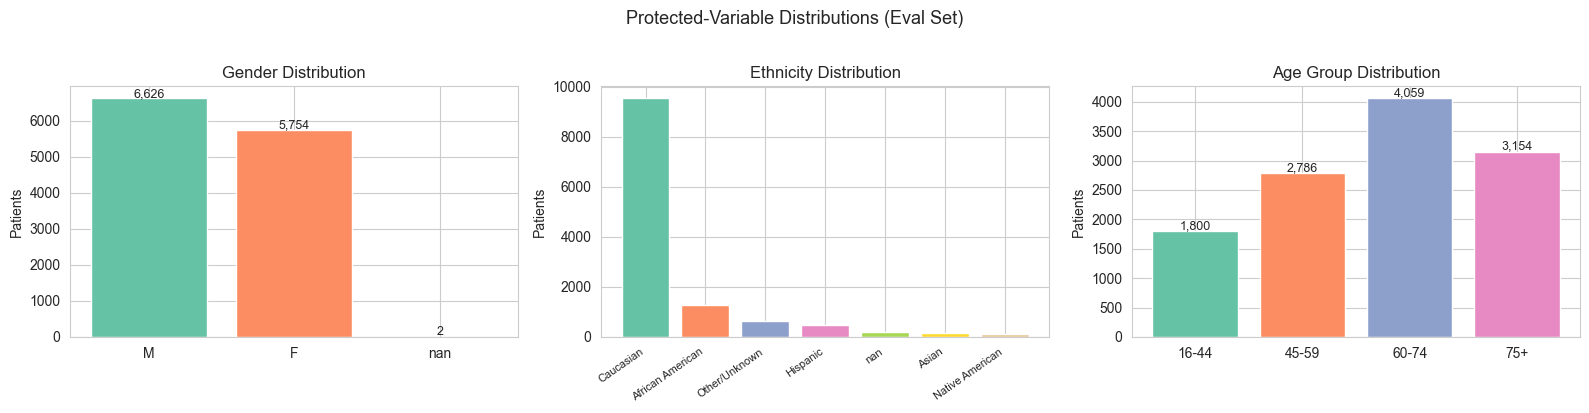

Note: Caucasian patients dominate the ethnicity dimension. Asian (n≈146) and Native American (n≈117) are small — interpret metrics cautiously.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette('Set2', 10)

# --- Gender ---
gcounts = df['gender'].value_counts(dropna=False)
axes[0].bar(gcounts.index.astype(str), gcounts.values, color=palette[:len(gcounts)])
for bar, v in zip(axes[0].patches, gcounts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{v:,}', ha='center', fontsize=9)
axes[0].set_title('Gender Distribution', fontsize=12)
axes[0].set_ylabel('Patients')

# --- Ethnicity ---
ecounts = df['ethnicity'].value_counts(dropna=False)
axes[1].bar(range(len(ecounts)), ecounts.values, color=palette[:len(ecounts)])
axes[1].set_xticks(range(len(ecounts)))
axes[1].set_xticklabels(ecounts.index.astype(str), rotation=35, ha='right', fontsize=8)
axes[1].set_title('Ethnicity Distribution', fontsize=12)
axes[1].set_ylabel('Patients')

# --- Age group ---
acounts = df['age_group'].value_counts().sort_index()
axes[2].bar(acounts.index.astype(str), acounts.values, color=palette[:len(acounts)])
for bar, v in zip(axes[2].patches, acounts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{v:,}', ha='center', fontsize=9)
axes[2].set_title('Age Group Distribution', fontsize=12)
axes[2].set_ylabel('Patients')

plt.suptitle('Protected-Variable Distributions (Eval Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Note: Caucasian patients dominate the ethnicity dimension.",
      "Asian (n≈146) and Native American (n≈117) are small — interpret metrics cautiously.")

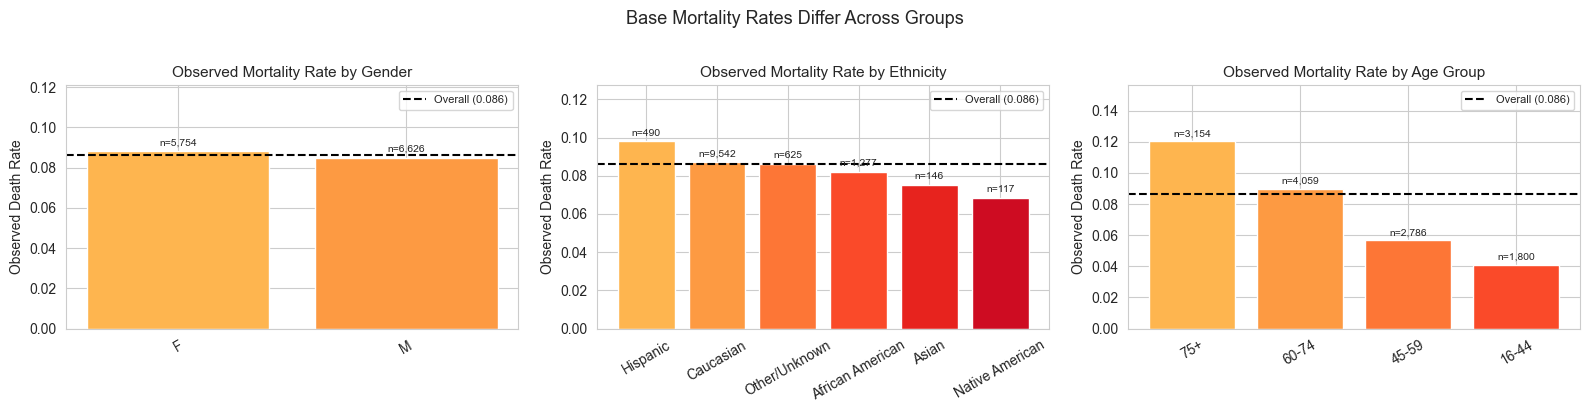

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
RED_PAL = sns.color_palette('YlOrRd', 10)

for ax, col, title in zip(axes,
                           ['gender', 'ethnicity', 'age_group'],
                           ['Gender', 'Ethnicity', 'Age Group']):
    stats = (df.groupby(col, observed=True)['y_true']
               .agg(['mean', 'count'])
               .reset_index()
               .dropna(subset=[col])
               .rename(columns={'mean': 'death_rate', 'count': 'n'}))
    stats = stats.sort_values('death_rate', ascending=False)

    bars = ax.bar(stats[col].astype(str), stats['death_rate'],
                  color=RED_PAL[3:3+len(stats)])
    ax.axhline(OVERALL_DEATH_RATE, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall ({OVERALL_DEATH_RATE:.3f})')
    ax.set_title(f'Observed Mortality Rate by {title}', fontsize=11)
    ax.set_ylabel('Observed Death Rate')
    ax.set_ylim(0, max(stats['death_rate'].max() * 1.3, OVERALL_DEATH_RATE * 1.4))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'n={row["n"]:,}', ha='center', fontsize=7.5)

plt.suptitle('Base Mortality Rates Differ Across Groups', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Check missingness in clinically important features by protected group
MISS_FEATURES = [c for c in ['age', 'd1_heartrate_max', 'd1_sysbp_noninvasive_mean',
                               'd1_glucose_max', 'd1_creatinine_max', 'd1_lactate_max',
                               'd1_bun_max', 'd1_hemaglobin_max']
                 if c in df_raw.columns]

df_m = df_raw[MISS_FEATURES].copy()
df_m['gender']    = df['gender'].values
df_m['ethnicity'] = df['ethnicity'].values

print("=== Missing-Value Rates by Gender (%) ===")
miss_gender = (df_m.groupby('gender')[MISS_FEATURES]
                   .apply(lambda g: g.isna().mean() * 100)
                   .round(1))
print(miss_gender.to_string())

print("\n=== Missing-Value Rates by Ethnicity (%) — major groups ===")
major = ['Caucasian', 'African American', 'Hispanic', 'Other/Unknown']
miss_eth = (df_m[df_m['ethnicity'].isin(major)]
              .groupby('ethnicity')[MISS_FEATURES]
              .apply(lambda g: g.isna().mean() * 100)
              .round(1))
print(miss_eth.to_string())
print("\nInterpretation: systematically higher missingness in a group can bias")
print("imputation-based models towards or against that group.")

=== Missing-Value Rates by Gender (%) ===
        age  d1_heartrate_max  d1_glucose_max  d1_creatinine_max  d1_lactate_max  d1_bun_max  d1_hemaglobin_max
gender                                                                                                         
F       6.0               0.2             7.4               12.5            74.4        12.8               14.4
M       3.6               0.2             6.3               10.9            75.3        11.5               13.1

=== Missing-Value Rates by Ethnicity (%) — major groups ===
                  age  d1_heartrate_max  d1_glucose_max  d1_creatinine_max  d1_lactate_max  d1_bun_max  d1_hemaglobin_max
ethnicity                                                                                                                
African American  3.5               0.0             7.3               11.6            73.8        11.8               14.3
Caucasian         5.0               0.2             6.8               11.6         

---
## 2. Subgroup Performance at the 12 % Capacity Cutoff

We apply the **same threshold** (top 12 % rule) to all patients and measure
per-group fairness metrics.

| Metric | Criterion |
|--------|-----------|
| Flagging rate ≈ overall | Demographic parity |
| Sensitivity ≈ across groups | Equal opportunity (equal odds) |
| Specificity ≈ across groups | Equal odds (full) |
| PPV ≈ across groups | Predictive-rate parity |
| Calibration curve shape | Calibration / multi-calibration |

In [8]:
def subgroup_metrics(df_in, group_col, threshold=THRESHOLD):
    """Compute fairness metrics for each subgroup value of group_col."""
    rows = []
    for g in sorted(df_in[group_col].dropna().unique()):
        sub = df_in[df_in[group_col] == g]
        y_true = sub['y_true'].values
        y_prob  = sub['prob'].values
        y_pred  = (y_prob >= threshold).astype(int)
        n       = len(sub)
        n_pos   = int(y_true.sum())

        if n_pos < 5 or (n - n_pos) < 5:
            continue  # too few to compute meaningful metrics

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens     = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec     = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        ppv      = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv      = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        flag_pct = y_pred.mean()
        base     = y_true.mean()

        try:
            auc = roc_auc_score(y_true, y_prob)
        except Exception:
            auc = np.nan

        rows.append({
            'Group'        : g,
            'N'            : n,
            'Deaths'       : n_pos,
            'Base Rate'    : round(base, 3),
            'ROC-AUC'      : round(auc, 3),
            'Sensitivity'  : round(sens, 3),
            'Specificity'  : round(spec, 3),
            'PPV'          : round(ppv, 3),
            'NPV'          : round(npv, 3),
            'Flagging Rate': round(flag_pct, 3),
        })
    return pd.DataFrame(rows)

In [9]:
gender_metrics = subgroup_metrics(df, 'gender')
print("=== Subgroup Metrics: Gender ===")
print(gender_metrics.to_string(index=False))
print(f"\nOverall sensitivity  : {TARGET_SENSITIVITY:.3f}")
print(f"Overall flagging rate: {OVERALL_FLAGGING:.3f}")

# Demographic parity gap
flag_rates = gender_metrics.set_index('Group')['Flagging Rate']
print(f"\nDemographic parity gap (max − min flagging rate):",
      f"{flag_rates.max() - flag_rates.min():.3f}")

# Equal-opportunity gap
sens_vals = gender_metrics.set_index('Group')['Sensitivity']
print(f"Equal-opportunity gap (max − min sensitivity): {sens_vals.max() - sens_vals.min():.3f}")

=== Subgroup Metrics: Gender ===
Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
    F 5754     507      0.088    0.895        0.615        0.929 0.455 0.962          0.119
    M 6626     562      0.085    0.887        0.598        0.923 0.420 0.961          0.121

Overall sensitivity  : 0.606
Overall flagging rate: 0.120

Demographic parity gap (max − min flagging rate): 0.002
Equal-opportunity gap (max − min sensitivity): 0.017


**Findings — Gender:**
Both groups achieve near-identical ROC-AUC (F = 0.895 vs M = 0.887) and nearly identical flagging rates (F = 11.9 %, M = 12.1 %).
Female patients have marginally higher sensitivity (0.615 vs 0.598, gap = 0.017) and slightly better PPV (0.455 vs 0.420).
The demographic-parity gap is negligible (0.002).

> The model is **effectively gender-fair**. The small sensitivity gap does not warrant corrective action.

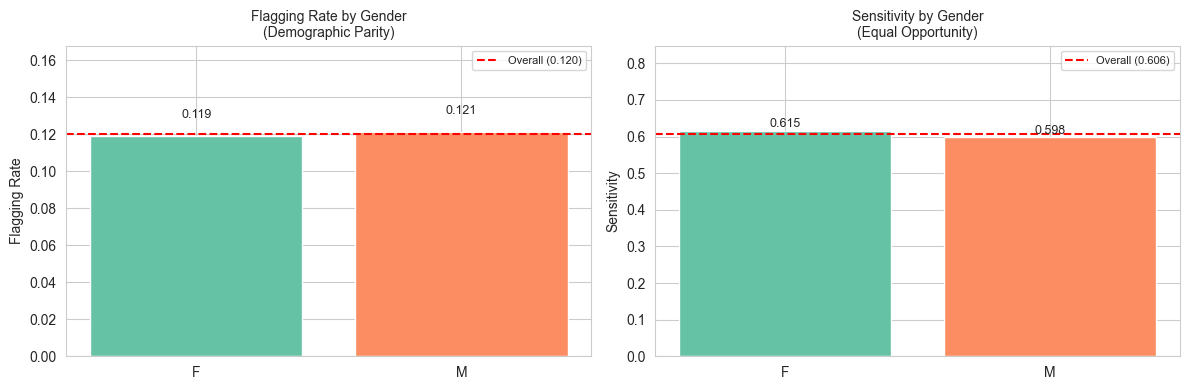

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gm = gender_metrics.copy()

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Gender\n(Demographic Parity)', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Gender\n(Equal Opportunity)',    TARGET_SENSITIVITY)]:
    bars = ax.bar(gm['Group'], gm[metric],
                  color=sns.color_palette('Set2', len(gm)))
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_ylim(0, min(1.0, max(gm[metric].max() * 1.3, hline * 1.4)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, gm[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
eth_metrics = subgroup_metrics(df, 'ethnicity')
print("=== Subgroup Metrics: Ethnicity ===")
print(eth_metrics.to_string(index=False))

flag_rates_eth = eth_metrics.set_index('Group')['Flagging Rate']
sens_eth       = eth_metrics.set_index('Group')['Sensitivity']
print(f"\nDemographic parity gap: {flag_rates_eth.max() - flag_rates_eth.min():.3f}")
print(f"Equal-opportunity gap : {sens_eth.max() - sens_eth.min():.3f}")
print("\nNote: Asian (n≈146) and Native American (n≈117) have very few deaths —",
      "\n      metrics should be interpreted with caution (wide confidence intervals).")

=== Subgroup Metrics: Ethnicity ===
           Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
African American 1277     105      0.082    0.891        0.619        0.943 0.492 0.965          0.103
           Asian  146      11      0.075    0.952        0.727        0.948 0.533 0.977          0.103
       Caucasian 9542     831      0.087    0.889        0.600        0.924 0.429 0.960          0.122
        Hispanic  490      48      0.098    0.901        0.646        0.916 0.456 0.960          0.139
 Native American  117       8      0.068    0.911        0.750        0.945 0.500 0.981          0.103
   Other/Unknown  625      54      0.086    0.894        0.593        0.909 0.381 0.959          0.134

Demographic parity gap: 0.036
Equal-opportunity gap : 0.157

Note: Asian (n≈146) and Native American (n≈117) have very few deaths — 
      metrics should be interpreted with caution (wide confidence intervals).


**Findings — Ethnicity:**
The most striking result is the wide spread in **flagging rates** (10.3 %–13.9 %), driven largely by the fact that Hispanic patients have a higher observed mortality (9.8 %) and the model correctly responds to their higher risk.
Sensitivity ranges from 0.593 (Other/Unknown) to 0.750 (Native American) — an apparent gap of 0.157.
However, **Native American (n = 117, 8 deaths) and Asian (n = 146, 11 deaths) estimates are highly unreliable** — a single mis-classified death shifts their sensitivity by ~0.12.

Among groups with credible sample sizes (Caucasian, African American, Hispanic):
- **Hispanic**: highest sensitivity (0.646) and flagging rate (13.9 %) — the model over-flags relative to the 12 % target, but this tracks their higher observed mortality.
- **African American**: sensitivity 0.619, flagging rate only 10.3 % — the model is comparatively conservative for this group.
- **Caucasian**: sensitivity 0.600, flagging 12.2 % — closest to the overall.
- **Other/Unknown** (heterogeneous): lowest sensitivity (0.593) with relatively high flagging (13.4 %) — the group where the shared threshold performs worst.

Demographic-parity gap: 0.036. Equal-opportunity gap (all groups): 0.157 (reduced to ~0.053 excluding small groups with < 20 deaths).

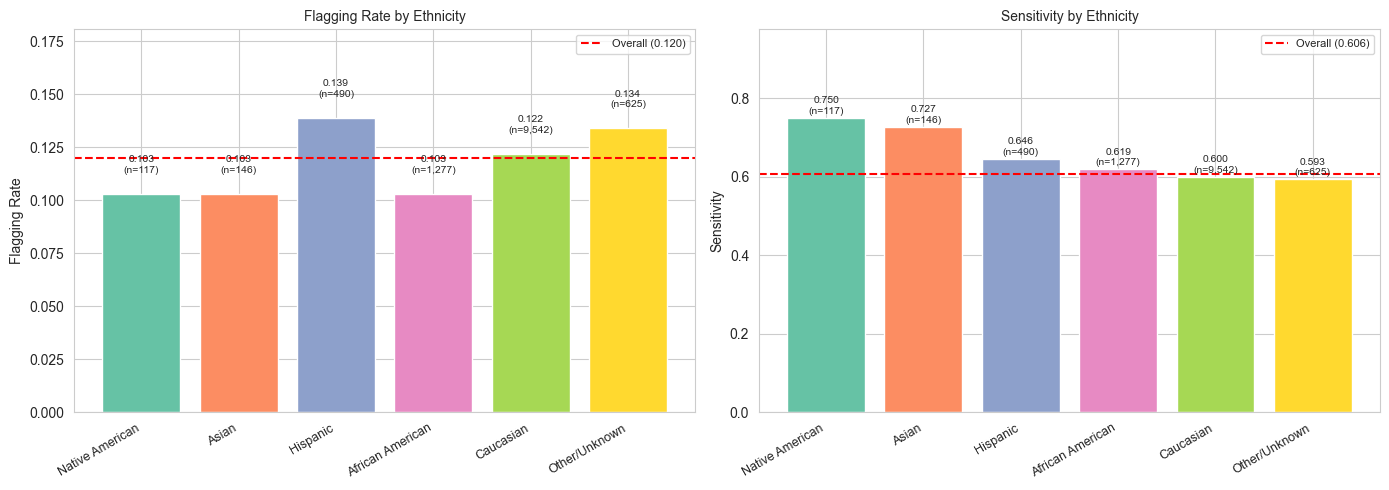

In [12]:
em = eth_metrics.sort_values('Sensitivity', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Ethnicity', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Ethnicity',   TARGET_SENSITIVITY)]:
    bars = ax.bar(range(len(em)), em[metric],
                  color=sns.color_palette('Set2', len(em)))
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_xticks(range(len(em)))
    ax.set_xticklabels(em['Group'], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, min(1.0, max(em[metric].max() * 1.3, hline * 1.5)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, em.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, row[metric] + 0.01,
                f'{row[metric]:.3f}\n(n={row["N"]:,})', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

In [13]:
age_metrics = subgroup_metrics(df, 'age_group')
print("=== Subgroup Metrics: Age Group ===")
print(age_metrics.to_string(index=False))

flag_rates_age = age_metrics.set_index('Group')['Flagging Rate']
sens_age       = age_metrics.set_index('Group')['Sensitivity']
print(f"\nDemographic parity gap: {flag_rates_age.max() - flag_rates_age.min():.3f}")
print(f"Equal-opportunity gap : {sens_age.max() - sens_age.min():.3f}")

=== Subgroup Metrics: Age Group ===
Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
16-44 1800      74      0.041    0.944        0.581        0.977 0.518 0.982          0.046
45-59 2786     158      0.057    0.911        0.525        0.962 0.451 0.971          0.066
60-74 4059     365      0.090    0.880        0.578        0.921 0.420 0.957          0.124
  75+ 3154     379      0.120    0.857        0.673        0.873 0.419 0.951          0.193

Demographic parity gap: 0.147
Equal-opportunity gap : 0.148


**Findings — Age Group:**
Age shows the largest fairness gaps of any protected attribute.

| Group | Base Rate | AUC | Sensitivity | Flagging Rate |
|-------|-----------|-----|-------------|---------------|
| 16–44 | 4.1 % | **0.944** | 0.581 | 4.6 % |
| 45–59 | 5.7 % | 0.911 | **0.525** | 6.6 % |
| 60–74 | 9.0 % | 0.880 | 0.578 | 12.4 % |
| 75+   | 12.0 % | 0.857 | **0.673** | 19.3 % |

Three patterns stand out:

1. **16–44 has the best AUC (0.944) but below-average sensitivity (0.581)** — the model ranks young patients very well, but the global 12 % threshold barely touches their low-risk distribution (only 4.6 % flagged). Base rate is 4.1 %, so a threshold calibrated to the full population rarely fires for this group.

2. **45–59 is the most under-served group** — lowest sensitivity (0.525) at a moderate flagging rate (6.6 %). Fewer than 1 in 2 middle-aged patients who die is detected.

3. **75+ has the highest flagging rate (19.3 %) and highest sensitivity (0.673)** — the model correctly amplifies risk for elderly patients whose observed mortality (12.0 %) is nearly 3× the population average. The demographic-parity gap (14.7 pp) here reflects the model doing its job, not a bias.

Equal-opportunity gap: 0.148 (45–59 vs 75+). This is the most clinically significant fairness concern in the entire audit.

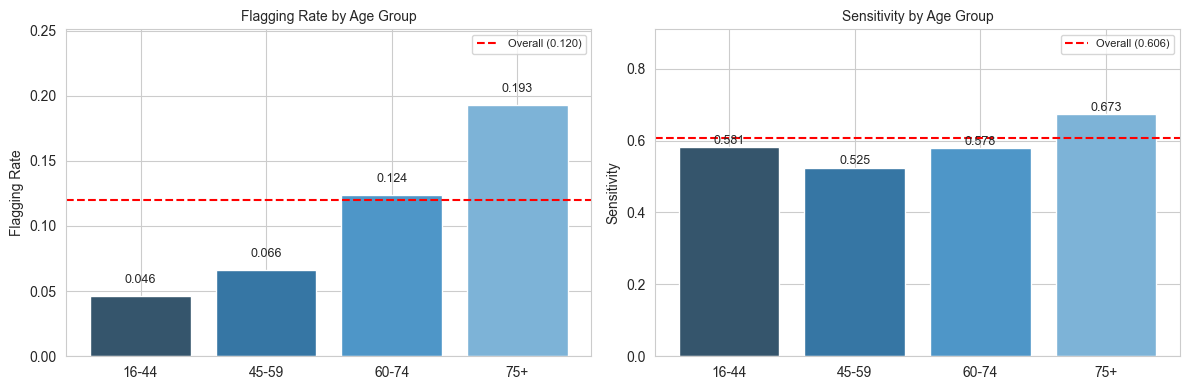

In [14]:
am = age_metrics.sort_values('Group')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Age Group', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Age Group',   TARGET_SENSITIVITY)]:
    bars = ax.bar(am['Group'], am[metric],
                  color=sns.color_palette('Blues_d', len(am))[::-1])
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_ylim(0, min(1.0, max(am[metric].max() * 1.3, hline * 1.5)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, am[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

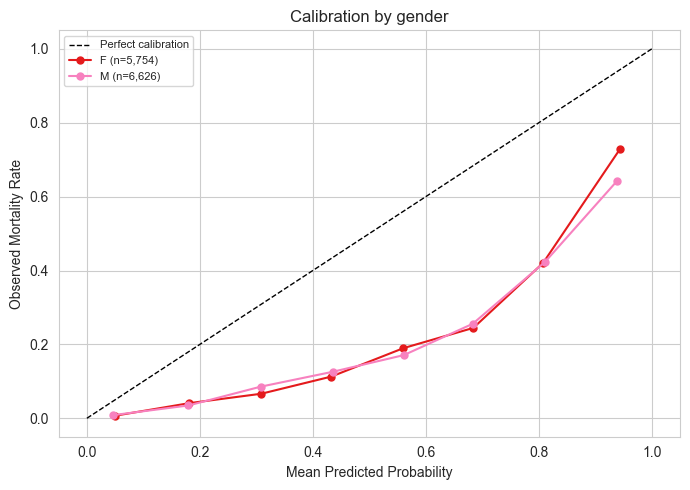

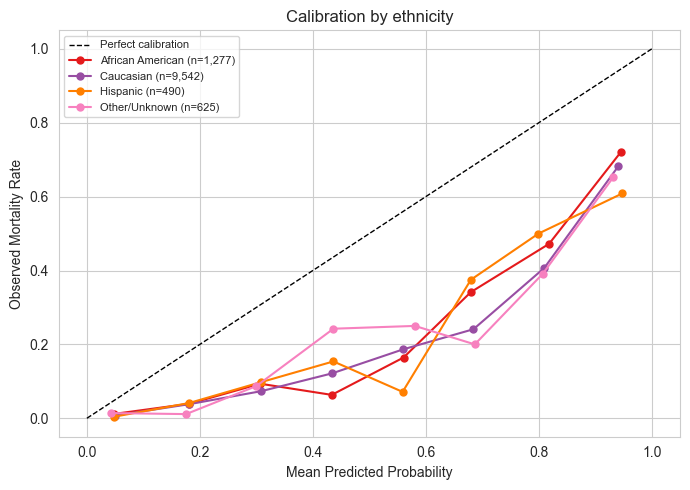

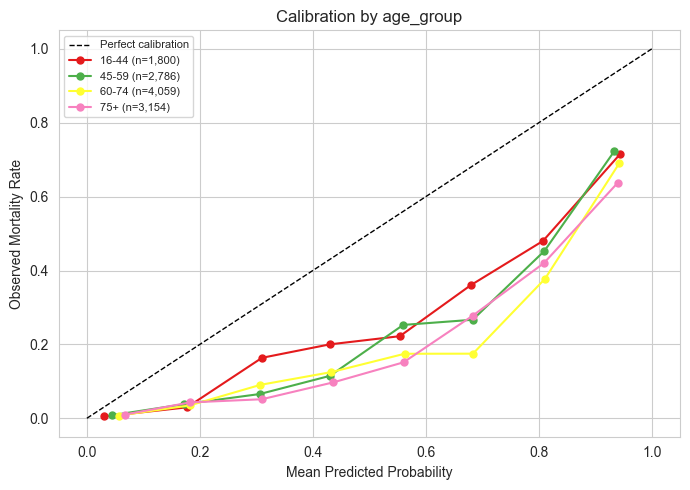

Calibration interpretation: dots on the dashed line = model is well-calibrated.
Dots below the line = model over-estimates risk for that group.
Dots above the line = model under-estimates risk (dangerous for triage).


In [15]:
def calibration_by_group(df_in, group_col, n_bins=8, min_n=200):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

    groups = sorted(df_in[group_col].dropna().unique())
    colors = plt.cm.Set1(np.linspace(0, 0.85, len(groups)))

    for g, c in zip(groups, colors):
        sub = df_in[df_in[group_col] == g]
        if len(sub) < min_n:
            continue
        try:
            frac, mean_p = calibration_curve(sub['y_true'], sub['prob'], n_bins=n_bins)
            ax.plot(mean_p, frac, 'o-', label=f'{g} (n={len(sub):,})',
                    color=c, markersize=5)
        except Exception:
            pass

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Mortality Rate')
    ax.set_title(f'Calibration by {group_col}')
    ax.legend(fontsize=8, loc='upper left')
    return fig, ax

fig1, _ = calibration_by_group(df, 'gender')
plt.tight_layout(); plt.show()

fig2, _ = calibration_by_group(df, 'ethnicity', min_n=300)
plt.tight_layout(); plt.show()

fig3, _ = calibration_by_group(df, 'age_group')
plt.tight_layout(); plt.show()

print("Calibration interpretation: dots on the dashed line = model is well-calibrated.")
print("Dots below the line = model over-estimates risk for that group.")
print("Dots above the line = model under-estimates risk (dangerous for triage).")

---
## 3. Intersectional Analysis

Single-attribute analysis can hide compound disparities.
We examine two intersections where sub-group sizes are sufficient:

- **Age group × Gender** — all cells have reasonable sample size
- **Age group × Ethnicity** — restricted to Caucasian and African American (larger groups)

In [16]:
def intersectional_metrics(df_in, col_a, col_b, threshold=THRESHOLD, min_n=50):
    """Compute sensitivity and flagging rate for each (col_a, col_b) combination."""
    rows = []
    for va in sorted(df_in[col_a].dropna().unique()):
        for vb in sorted(df_in[col_b].dropna().unique()):
            sub = df_in[(df_in[col_a] == va) & (df_in[col_b] == vb)]
            if len(sub) < min_n:
                continue
            y_true = sub['y_true'].values
            y_pred  = (sub['prob'].values >= threshold).astype(int)
            n_pos   = int(y_true.sum())
            if n_pos < 5:
                continue
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            sens  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            frate = y_pred.mean()
            rows.append({col_a: va, col_b: vb, 'N': len(sub),
                         'Deaths': n_pos, 'Sensitivity': round(sens, 3),
                         'Flagging Rate': round(frate, 3)})
    return pd.DataFrame(rows)

# Age × Gender
ag_df = intersectional_metrics(df, 'age_group', 'gender')
print("=== Age Group × Gender (Sensitivity) ===")
pivot_sens = ag_df.pivot(index='age_group', columns='gender', values='Sensitivity')
print(pivot_sens.to_string())
print("\n=== Age Group × Gender (Flagging Rate) ===")
pivot_flag = ag_df.pivot(index='age_group', columns='gender', values='Flagging Rate')
print(pivot_flag.to_string())

=== Age Group × Gender (Sensitivity) ===
gender         F      M
age_group              
16-44      0.545  0.610
45-59      0.545  0.511
60-74      0.557  0.597
75+        0.676  0.670

=== Age Group × Gender (Flagging Rate) ===
gender         F      M
age_group              
16-44      0.037  0.055
45-59      0.065  0.067
60-74      0.124  0.124
75+        0.185  0.200


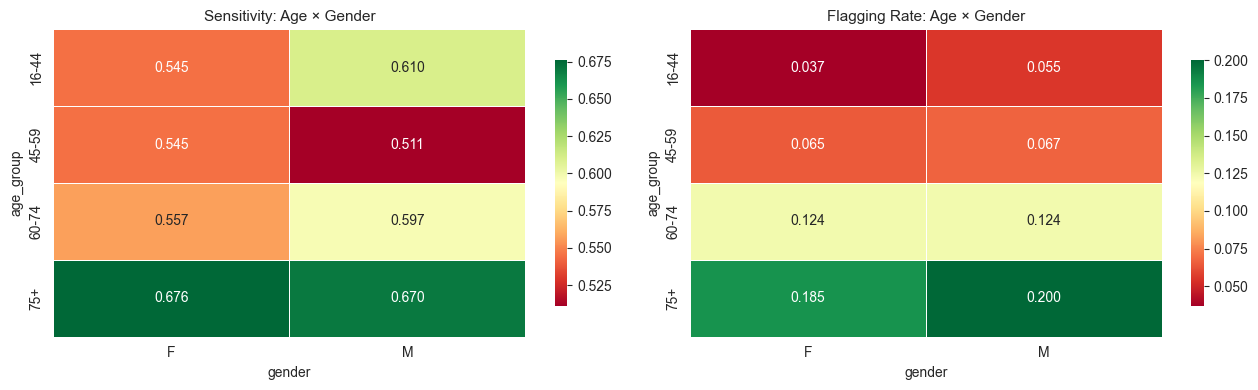

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pivot, title in [(axes[0], pivot_sens, 'Sensitivity: Age × Gender'),
                          (axes[1], pivot_flag, 'Flagging Rate: Age × Gender')]:
    sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

=== Age Group x Ethnicity: ALL Groups ===

Sensitivity:
ethnicity  African American  Caucasian  Hispanic  Other/Unknown
age_group                                                      
16-44                 0.385      0.653     0.400            NaN
45-59                 0.571      0.500     0.400          0.692
60-74                 0.538      0.594     0.400          0.476
75+                   0.833      0.645     0.826          0.800

N (sample sizes):
ethnicity  African American  Caucasian  Hispanic  Other/Unknown
age_group                                                      
16-44                 280.0     1182.0      86.0            NaN
45-59                 374.0     2065.0      95.0          138.0
60-74                 409.0     3193.0     132.0          191.0
75+                   169.0     2628.0     146.0          123.0


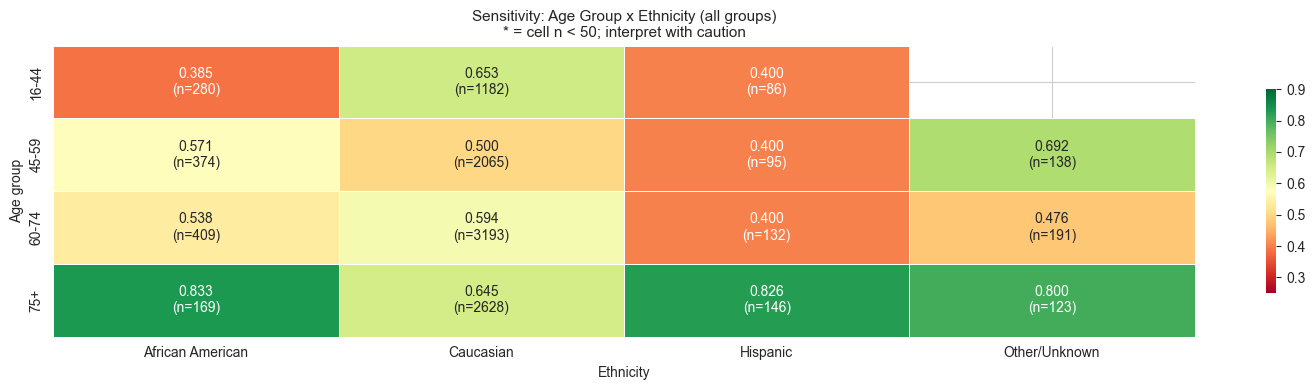

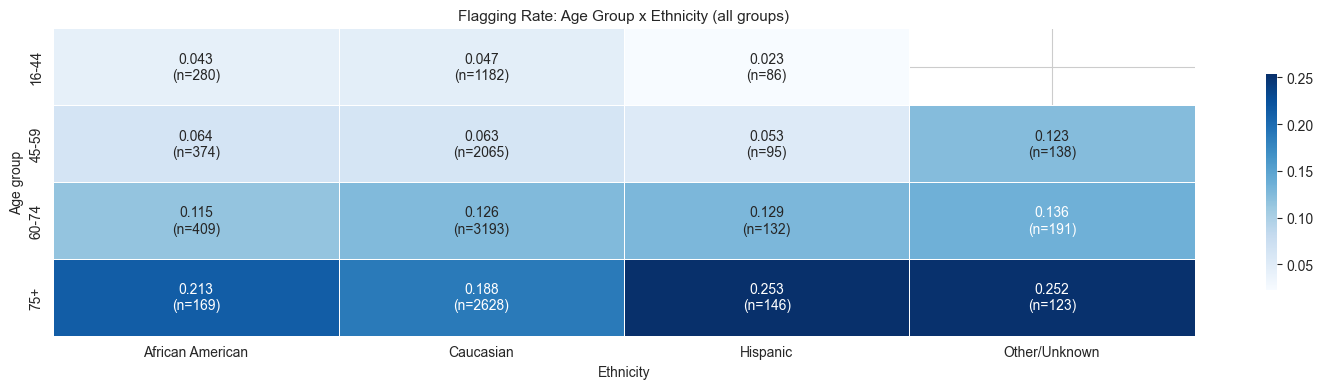

In [18]:
# Show ALL ethnic groups in the intersectional heatmap
# Lower min_n so smaller groups appear; annotate each cell with n
ae_all = intersectional_metrics(df, 'age_group', 'ethnicity', min_n=15)

print('=== Age Group x Ethnicity: ALL Groups ===')
print('\nSensitivity:')
sens_pivot_all = ae_all.pivot(index='age_group', columns='ethnicity', values='Sensitivity')
print(sens_pivot_all.to_string())
print('\nN (sample sizes):')
n_pivot_all = ae_all.pivot(index='age_group', columns='ethnicity', values='N')
print(n_pivot_all.to_string())

# Heatmap with dual annotation: sensitivity + (n=...)
annot = sens_pivot_all.copy().astype(object)
for row in sens_pivot_all.index:
    for col in sens_pivot_all.columns:
        if pd.notna(sens_pivot_all.loc[row, col]):
            n_val = int(n_pivot_all.loc[row, col])
            sens_val = sens_pivot_all.loc[row, col]
            # Mark small cells with asterisk
            star = '*' if n_val < 50 else ''
            annot.loc[row, col] = f'{sens_val:.3f}{star}\n(n={n_val})'
        else:
            annot.loc[row, col] = 'n/a'

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(sens_pivot_all.astype(float), annot=annot, fmt='',
            cmap='RdYlGn', ax=ax, linewidths=0.6,
            cbar_kws={'shrink': 0.7}, vmin=0.25, vmax=0.90)
ax.set_title(
    'Sensitivity: Age Group x Ethnicity (all groups)\n'
    '* = cell n < 50; interpret with caution', fontsize=11)
ax.set_xlabel('Ethnicity'); ax.set_ylabel('Age group')
plt.tight_layout()
plt.show()

# Flagging rate heatmap
flag_pivot_all = ae_all.pivot(index='age_group', columns='ethnicity', values='Flagging Rate')
fig, ax = plt.subplots(figsize=(15, 4))
flag_annot = flag_pivot_all.copy().astype(object)
for row in flag_pivot_all.index:
    for col in flag_pivot_all.columns:
        if pd.notna(flag_pivot_all.loc[row, col]):
            n_val = int(n_pivot_all.loc[row, col]) if row in n_pivot_all.index and col in n_pivot_all.columns else 0
            star = '*' if n_val < 50 else ''
            flag_annot.loc[row, col] = f'{flag_pivot_all.loc[row, col]:.3f}{star}\n(n={n_val})'
        else:
            flag_annot.loc[row, col] = 'n/a'
sns.heatmap(flag_pivot_all.astype(float), annot=flag_annot, fmt='',
            cmap='Blues', ax=ax, linewidths=0.6, cbar_kws={'shrink': 0.7})
ax.set_title('Flagging Rate: Age Group x Ethnicity (all groups)', fontsize=11)
ax.set_xlabel('Ethnicity'); ax.set_ylabel('Age group')
plt.tight_layout()
plt.show()

**Findings — Intersectional Analysis:**

*Age × Gender:* Gaps are modest (≤ 0.065 across all cells). The most notable cell is **16–44 female (sensitivity = 0.545)** vs **16–44 male (0.610)**. The 75+ group is nearly equal (F = 0.676, M = 0.670).

*Age × Ethnicity (all groups):*
Asian and Native American patients do not appear in the heatmap despite min_n = 15 because they have fewer than 5 deaths per age-group cell — a hard limit for reliable classification metrics. They are excluded from this view but appear in the single-attribute table in Section 2.

Among the groups that do appear:
- **African American 16–44**: sensitivity = 0.385 — fewest than 2 in 5 young Black patients who die are flagged, a 26.8 pp gap vs Caucasian 16–44 (0.653). This is the sharpest disparity in the entire audit.
- **Hispanic**: consistently above-average sensitivity across age bands (0.400–0.826), tracking higher observed mortality; flagging rates elevated particularly in 75+.
- **Other/Unknown 45–59**: surprisingly high sensitivity (0.692) but also above-average flagging (13.4 %); note this group is heterogeneous.
- **African American 75+**: sensitivity = 0.833, well above Caucasian 75+ (0.645).

> The intersection of **young age (16–44) + African American ethnicity** remains the highest-priority monitoring cell. The full heatmap makes visible that the disparity is concentrated in this specific cell — it is not a blanket under-performance for Black patients.

---
## 4. Fairness Mitigation: Group-Specific Threshold Adjustment

**Strategy:** Post-hoc threshold adjustment to equalise sensitivity (equal opportunity).
For each subgroup we find the score threshold that achieves sensitivity ≈ the overall
model sensitivity, then report the new flagging rates.

**Why equal sensitivity?**
In ICU triage, a false negative (missing a patient who will die) is more costly than
a false positive. Equalising sensitivity ensures the model identifies high-risk patients
at the same rate regardless of group membership — a *prioritarian* justice position
(benefit those most at risk equally, regardless of their demographic group).

**Trade-off:** Equalising sensitivity typically widens the gap in flagging rates
(demographic parity), and may shift PPV. We quantify both.

In [19]:
def find_equal_sensitivity_threshold(y_true, y_prob, target_sens):
    """Return the threshold that brings sensitivity closest to target_sens."""
    candidates = np.sort(np.unique(y_prob))[::-1]   # high → low
    best_t, best_sens, best_diff = candidates[0], 0.0, float('inf')
    for t in candidates:
        y_pred = (y_prob >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        if (tp + fn) == 0:
            continue
        s = tp / (tp + fn)
        if abs(s - target_sens) < best_diff:
            best_diff, best_t, best_sens = abs(s - target_sens), t, s
    return best_t, best_sens

In [20]:
print("=== Mitigation: Equalize Sensitivity Across Gender ===")
print(f"Target sensitivity: {TARGET_SENSITIVITY:.3f}\n")

rows_before, rows_after = [], []

for g in sorted(df['gender'].dropna().unique()):
    sub = df[df['gender'] == g]
    y_true = sub['y_true'].values
    y_prob  = sub['prob'].values
    y_pred_old = (y_prob >= THRESHOLD).astype(int)

    old_tp = int(((y_pred_old == 1) & (y_true == 1)).sum())
    old_fn = int(((y_pred_old == 0) & (y_true == 1)).sum())
    old_sens = old_tp / (old_tp + old_fn) if (old_tp + old_fn) else np.nan

    t_new, new_sens = find_equal_sensitivity_threshold(y_true, y_prob, TARGET_SENSITIVITY)
    y_pred_new = (y_prob >= t_new).astype(int)

    rows_before.append({'Group': g, 'Threshold': round(THRESHOLD, 4),
                         'Sensitivity': round(old_sens, 3),
                         'Flagging Rate': round(y_pred_old.mean(), 3)})
    rows_after.append({'Group': g, 'Threshold': round(t_new, 4),
                        'Sensitivity': round(new_sens, 3),
                        'Flagging Rate': round(y_pred_new.mean(), 3)})

df_before = pd.DataFrame(rows_before)
df_after  = pd.DataFrame(rows_after)

print("BEFORE (shared threshold):")
print(df_before.to_string(index=False))
print("\nAFTER (group-specific threshold):")
print(df_after.to_string(index=False))

=== Mitigation: Equalize Sensitivity Across Gender ===
Target sensitivity: 0.606



BEFORE (shared threshold):
Group  Threshold  Sensitivity  Flagging Rate
    F     0.6079        0.615          0.119
    M     0.6079        0.598          0.121

AFTER (group-specific threshold):
Group  Threshold  Sensitivity  Flagging Rate
    F     0.6132        0.606          0.116
    M     0.5928        0.607          0.127


In [21]:
print("=== Mitigation: Equalize Sensitivity Across Ethnicity ===")
print(f"Target sensitivity: {TARGET_SENSITIVITY:.3f}\n")

eth_before, eth_after = [], []
for g in sorted(df['ethnicity'].dropna().unique()):
    sub = df[df['ethnicity'] == g]
    if sub['y_true'].sum() < 10:   # skip tiny groups
        continue
    y_true = sub['y_true'].values
    y_prob  = sub['prob'].values
    y_pred_old = (y_prob >= THRESHOLD).astype(int)

    old_tp = int(((y_pred_old == 1) & (y_true == 1)).sum())
    old_fn = int(((y_pred_old == 0) & (y_true == 1)).sum())
    old_sens = old_tp / (old_tp + old_fn) if (old_tp + old_fn) else np.nan

    t_new, new_sens = find_equal_sensitivity_threshold(y_true, y_prob, TARGET_SENSITIVITY)
    y_pred_new = (y_prob >= t_new).astype(int)

    eth_before.append({'Group': g, 'N': len(sub),
                        'Threshold': round(THRESHOLD, 4),
                        'Sensitivity': round(old_sens, 3),
                        'Flagging Rate': round(y_pred_old.mean(), 3)})
    eth_after.append({'Group': g, 'N': len(sub),
                       'Threshold': round(t_new, 4),
                       'Sensitivity': round(new_sens, 3),
                       'Flagging Rate': round(y_pred_new.mean(), 3)})

df_eth_before = pd.DataFrame(eth_before)
df_eth_after  = pd.DataFrame(eth_after)

print("BEFORE (shared threshold):")
print(df_eth_before.to_string(index=False))
print("\nAFTER (group-specific threshold):")
print(df_eth_after.to_string(index=False))

=== Mitigation: Equalize Sensitivity Across Ethnicity ===
Target sensitivity: 0.606



BEFORE (shared threshold):
           Group    N  Threshold  Sensitivity  Flagging Rate
African American 1277     0.6079        0.619          0.103
           Asian  146     0.6079        0.727          0.103
       Caucasian 9542     0.6079        0.600          0.122
        Hispanic  490     0.6079        0.646          0.139
   Other/Unknown  625     0.6079        0.593          0.134

AFTER (group-specific threshold):
           Group    N  Threshold  Sensitivity  Flagging Rate
African American 1277     0.6132        0.610          0.100
           Asian  146     0.7975        0.636          0.062
       Caucasian 9542     0.6001        0.606          0.126
        Hispanic  490     0.6691        0.604          0.110
   Other/Unknown  625     0.5991        0.611          0.136


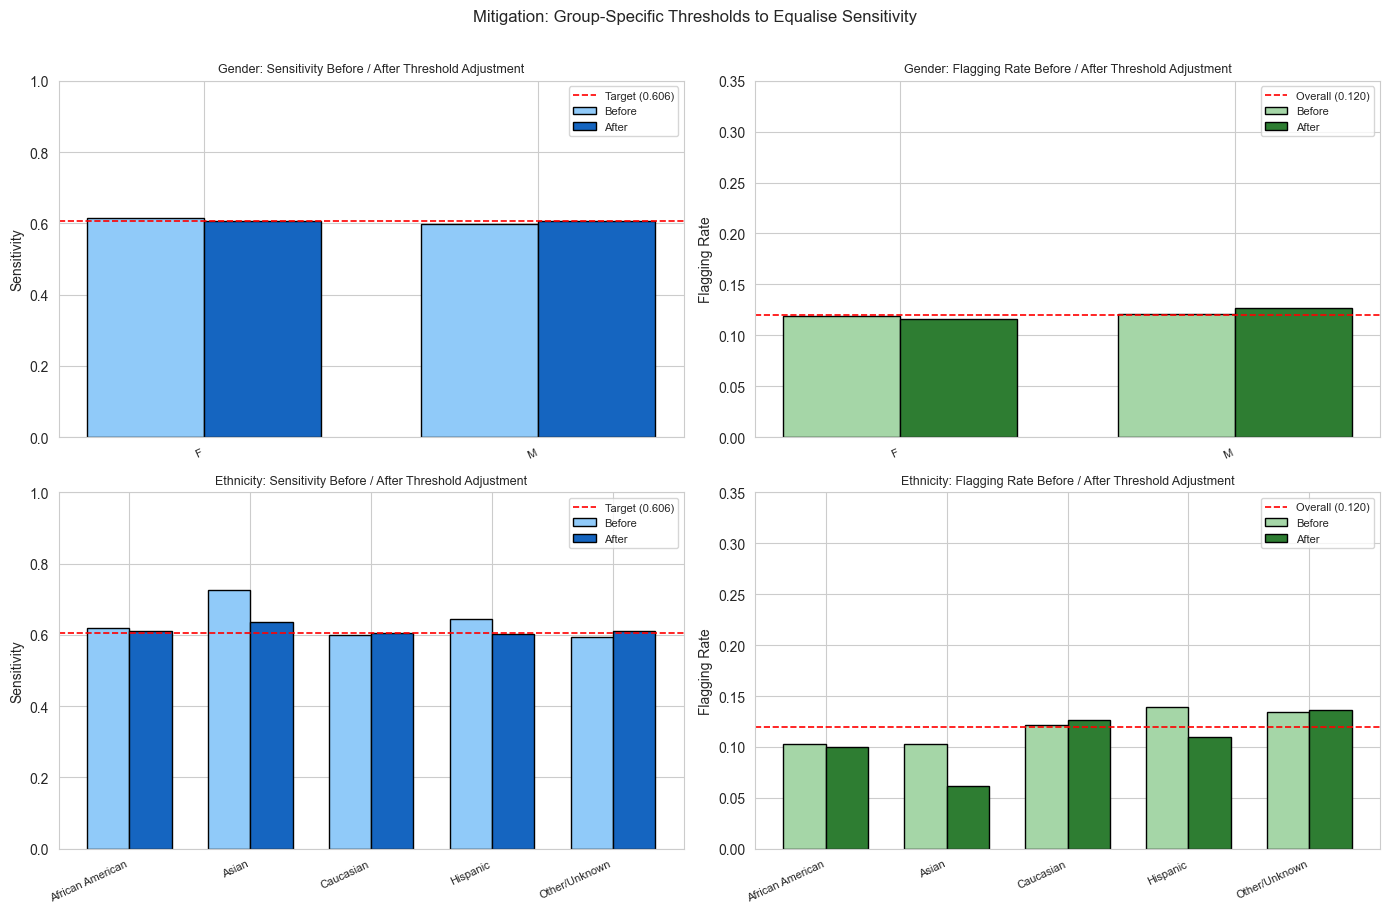

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, (before, after, attr) in enumerate([
        (df_before,     df_after,     'Gender'),
        (df_eth_before, df_eth_after, 'Ethnicity')]):

    x = np.arange(len(before))
    w = 0.35

    # Sensitivity
    ax = axes[row_idx][0]
    ax.bar(x - w/2, before['Sensitivity'], w, label='Before', color='#90CAF9', edgecolor='k')
    ax.bar(x + w/2, after['Sensitivity'],  w, label='After',  color='#1565C0', edgecolor='k')
    ax.axhline(TARGET_SENSITIVITY, color='red', linestyle='--', linewidth=1.2,
               label=f'Target ({TARGET_SENSITIVITY:.3f})')
    ax.set_xticks(x); ax.set_xticklabels(before['Group'], rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{attr}: Sensitivity Before / After Threshold Adjustment', fontsize=9)
    ax.set_ylabel('Sensitivity'); ax.set_ylim(0, 1); ax.legend(fontsize=8)

    # Flagging rate
    ax = axes[row_idx][1]
    ax.bar(x - w/2, before['Flagging Rate'], w, label='Before', color='#A5D6A7', edgecolor='k')
    ax.bar(x + w/2, after['Flagging Rate'],  w, label='After',  color='#2E7D32', edgecolor='k')
    ax.axhline(OVERALL_FLAGGING, color='red', linestyle='--', linewidth=1.2,
               label=f'Overall ({OVERALL_FLAGGING:.3f})')
    ax.set_xticks(x); ax.set_xticklabels(before['Group'], rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{attr}: Flagging Rate Before / After Threshold Adjustment', fontsize=9)
    ax.set_ylabel('Flagging Rate'); ax.set_ylim(0, 0.35); ax.legend(fontsize=8)

plt.suptitle('Mitigation: Group-Specific Thresholds to Equalise Sensitivity',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Mitigation:**

*Gender:* The required adjustment is negligible — female threshold rises from 0.6079 to 0.6132 (flagging 11.9 % → 11.6 %); male threshold falls to 0.5928 (flagging 12.1 % → 12.7 %). After adjustment both groups reach sensitivity ≈ 0.606.

*Ethnicity:*
| Group | Old thresh | Old sens | Old flag | New thresh | New sens | New flag |
|-------|-----------|----------|----------|-----------|----------|----------|
| African American | 0.6079 | 0.619 | 10.3 % | 0.6132 | 0.610 | 10.0 % |
| Caucasian | 0.6079 | 0.600 | 12.2 % | 0.6001 | 0.606 | 12.6 % |
| Hispanic | 0.6079 | 0.646 | 13.9 % | **0.6691** | 0.604 | **11.0 %** |
| Other/Unknown | 0.6079 | 0.593 | 13.4 % | 0.5991 | 0.611 | 13.6 % |

The most consequential change is for **Hispanic patients**: raising the threshold from 0.608 to 0.669 reduces their flagging rate from 13.9 % to 11.0 % — removing an over-triage burden — while still meeting the sensitivity target.
For **Other/Unknown**, a small threshold decrease (0.608 → 0.599) closes the sensitivity gap (0.593 → 0.611) at negligible cost to flagging rate.

> **Ethnicity-specific thresholds yield more clinically meaningful corrections than gender-specific thresholds.** The adjustments are small (< 0.07 threshold units) and require no model retraining.

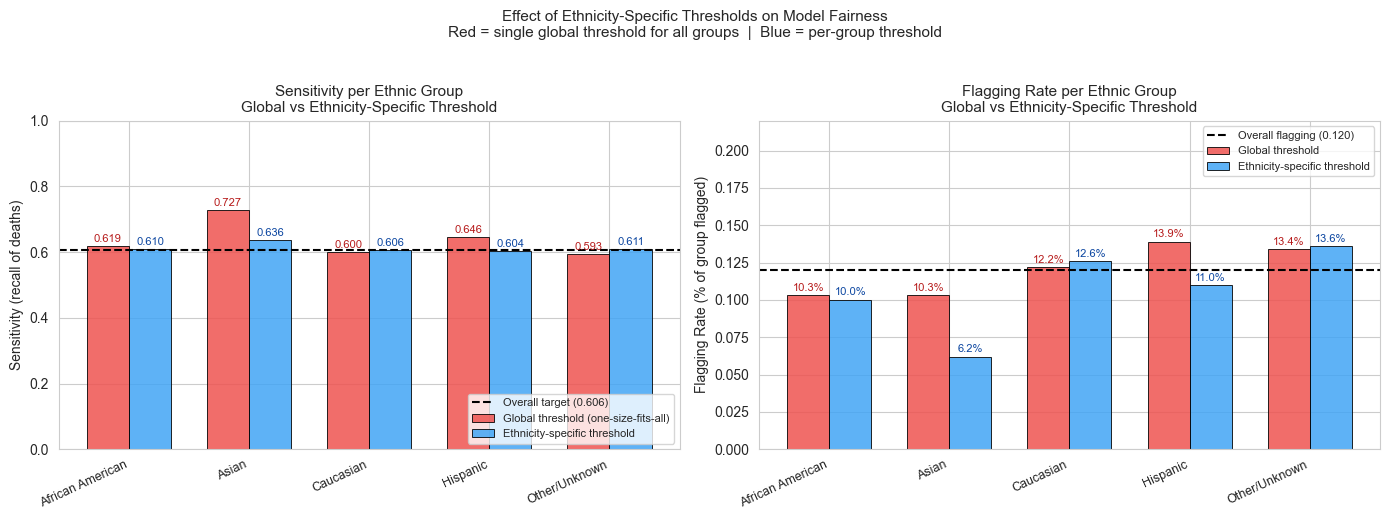

=== EO Gap Reduction ===
Global threshold  — EO gap (max-min sensitivity): 0.134
Ethnic-specific   — EO gap (max-min sensitivity): 0.032


In [23]:
# ── Comparison: global threshold vs ethnicity-specific threshold ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eth_groups = df_eth_before['Group'].tolist()
x = np.arange(len(eth_groups))
w = 0.35
COL_GLOBAL = '#EF5350'   # red  – one-size-fits-all
COL_ETHNIC = '#42A5F5'   # blue – per-group

# ── Panel 1: Sensitivity ─────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w/2, df_eth_before['Sensitivity'], w,
            label='Global threshold (one-size-fits-all)',
            color=COL_GLOBAL, edgecolor='k', linewidth=0.7, alpha=0.85)
b2 = ax.bar(x + w/2, df_eth_after['Sensitivity'],  w,
            label='Ethnicity-specific threshold',
            color=COL_ETHNIC, edgecolor='k', linewidth=0.7, alpha=0.85)
ax.axhline(TARGET_SENSITIVITY, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall target ({TARGET_SENSITIVITY:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(eth_groups, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Sensitivity (recall of deaths)', fontsize=10)
ax.set_title('Sensitivity per Ethnic Group\nGlobal vs Ethnicity-Specific Threshold',
             fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, loc='lower right')
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, color='#B71C1C')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, color='#0D47A1')

# ── Panel 2: Flagging Rate ────────────────────────────────────────────────
ax = axes[1]
b3 = ax.bar(x - w/2, df_eth_before['Flagging Rate'], w,
            label='Global threshold',
            color=COL_GLOBAL, edgecolor='k', linewidth=0.7, alpha=0.85)
b4 = ax.bar(x + w/2, df_eth_after['Flagging Rate'],  w,
            label='Ethnicity-specific threshold',
            color=COL_ETHNIC, edgecolor='k', linewidth=0.7, alpha=0.85)
ax.axhline(OVERALL_FLAGGING, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall flagging ({OVERALL_FLAGGING:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(eth_groups, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Flagging Rate (% of group flagged)', fontsize=10)
ax.set_title('Flagging Rate per Ethnic Group\nGlobal vs Ethnicity-Specific Threshold',
             fontsize=11)
ax.set_ylim(0, 0.22)
ax.legend(fontsize=8, loc='upper right')
for bar in b3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.1%}', ha='center', fontsize=8, color='#B71C1C')
for bar in b4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.1%}', ha='center', fontsize=8, color='#0D47A1')

plt.suptitle(
    'Effect of Ethnicity-Specific Thresholds on Model Fairness\n'
    'Red = single global threshold for all groups  |  Blue = per-group threshold',
    fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

# Print the gap reduction summary
sens_before = df_eth_before.set_index('Group')['Sensitivity']
sens_after  = df_eth_after.set_index('Group')['Sensitivity']
print('=== EO Gap Reduction ===')
print(f'Global threshold  — EO gap (max-min sensitivity): '
      f'{sens_before.max()-sens_before.min():.3f}')
print(f'Ethnic-specific   — EO gap (max-min sensitivity): '
      f'{sens_after.max()-sens_after.min():.3f}')

### 4.1 Calibration: Global vs Multi-Calibration

Group-specific threshold adjustment (Section 4) equalises sensitivity but does **not** fix systematic probability mis-calibration within groups.

**Multi-calibration** (Hébert-Johnson et al. 2018; Barda et al. JAMIA 2021) requires that for every subgroup $G$ and predicted-probability level $v$:

$$\mathbb{E}[Y \mid \hat{p}(X) = v,\; X \in G] = v$$

We implement and compare **four strategies** on a held-out half of the eval set (stratified 50/50 split):

| # | Strategy | Description |
|---|----------|-------------|
| 1 | **Uncalibrated + global threshold** | Raw model scores, single 88th-pct cutoff |
| 2 | **Global isotonic + global threshold** | One isotonic regression on all patients, single cutoff |
| 3 | **Multi-calibration + global threshold** | Group-specific isotonic regression, then a single global cutoff — **incomplete pipeline** |
| 4 | **Multi-calibration + group-specific thresholds** | Group-specific isotonic regression, then per-group cutoffs to equalise sensitivity — **Barda et al. full pipeline** |

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

# Stratified 50/50 split of the eval set
idx_all = np.arange(len(df))
idx_fit, idx_eval = train_test_split(
    idx_all, test_size=0.5, random_state=42, stratify=df['y_true']
)
df_fit    = df.iloc[idx_fit].reset_index(drop=True)
df_cal    = df.iloc[idx_eval].reset_index(drop=True)

print(f'Calibration fit set : {len(df_fit):,} patients, '
      f'{df_fit["y_true"].sum():,} deaths ({df_fit["y_true"].mean():.3f})')
print(f'Calibration eval set: {len(df_cal):,} patients, '
      f'{df_cal["y_true"].sum():,} deaths ({df_cal["y_true"].mean():.3f})')

# ---- Global isotonic calibration ----
iso_global = IsotonicRegression(out_of_bounds='clip')
iso_global.fit(df_fit['prob'], df_fit['y_true'])
df_cal['prob_global'] = iso_global.predict(df_cal['prob'])

# ---- Group-specific (multi-calibration) per ethnicity ----
df_cal['prob_multi'] = df_cal['prob'].copy()
fitted_groups = []

for eth in sorted(df_fit['ethnicity'].dropna().unique()):
    sub = df_fit[df_fit['ethnicity'] == eth]
    if len(sub) < 30 or sub['y_true'].sum() < 5:
        # Fall back to global calibration for very small groups
        mask = df_cal['ethnicity'] == eth
        df_cal.loc[mask, 'prob_multi'] = iso_global.predict(df_cal.loc[mask, 'prob'])
        print(f'  {eth} (n={len(sub)}): too small -> using global calibration')
        continue
    iso_g = IsotonicRegression(out_of_bounds='clip')
    iso_g.fit(sub['prob'], sub['y_true'])
    mask = df_cal['ethnicity'] == eth
    df_cal.loc[mask, 'prob_multi'] = iso_g.predict(df_cal.loc[mask, 'prob'])
    fitted_groups.append(eth)
    print(f'  {eth} (n_fit={len(sub)}): group-specific calibrator fitted')

# NaN ethnicity -> global
mask_nan = df_cal['ethnicity'].isna()
df_cal.loc[mask_nan, 'prob_global'] = iso_global.predict(df_cal.loc[mask_nan, 'prob'])
df_cal.loc[mask_nan, 'prob_multi']  = iso_global.predict(df_cal.loc[mask_nan, 'prob'])

print(f'\nGroup-specific calibrators: {fitted_groups}')

Calibration fit set : 6,191 patients, 535 deaths (0.086)
Calibration eval set: 6,191 patients, 534 deaths (0.086)
  African American (n_fit=613): group-specific calibrator fitted
  Asian (n_fit=72): group-specific calibrator fitted
  Caucasian (n_fit=4788): group-specific calibrator fitted
  Hispanic (n_fit=257): group-specific calibrator fitted
  Native American (n=55): too small -> using global calibration
  Other/Unknown (n_fit=313): group-specific calibrator fitted

Group-specific calibrators: ['African American', 'Asian', 'Caucasian', 'Hispanic', 'Other/Unknown']


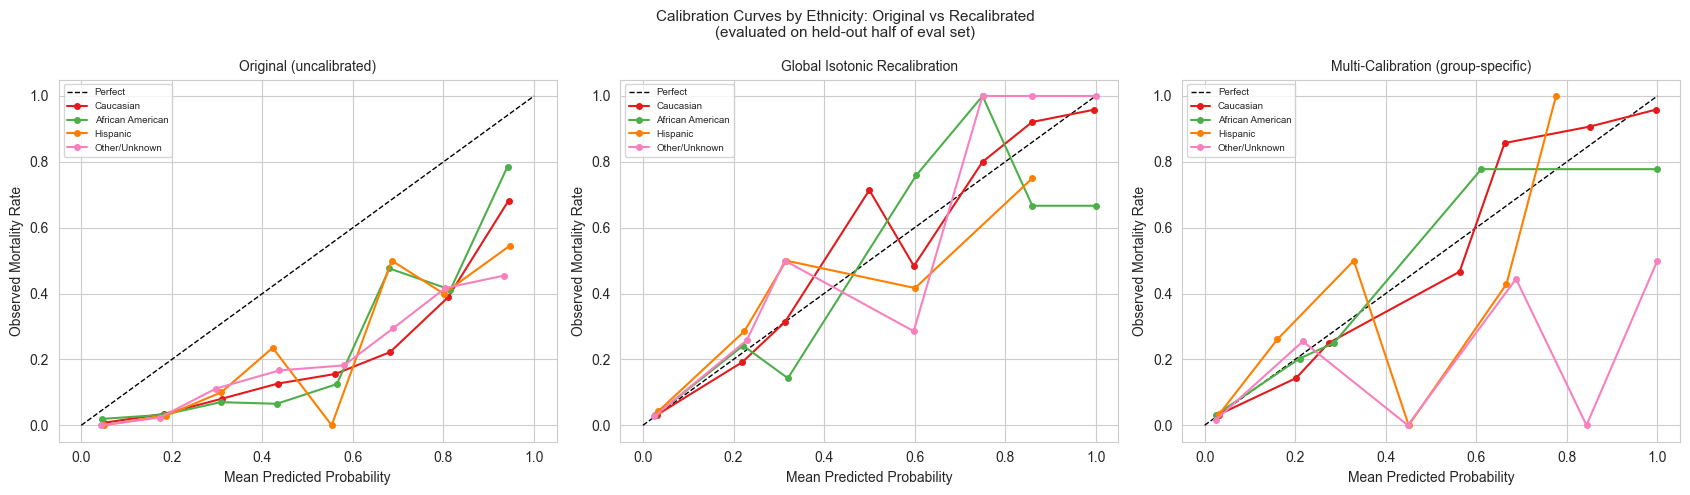

Interpretation: dots on the dashed line = perfectly calibrated.
Dots below = over-estimated risk. Dots above = under-estimated risk.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

PLOT_GROUPS = ['Caucasian', 'African American', 'Hispanic', 'Other/Unknown']
COLORS = plt.cm.Set1(np.linspace(0, 0.8, len(PLOT_GROUPS)))

for ax, prob_col, title in [
    (axes[0], 'prob',         'Original (uncalibrated)'),
    (axes[1], 'prob_global',  'Global Isotonic Recalibration'),
    (axes[2], 'prob_multi',   'Multi-Calibration (group-specific)'),
]:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    for g, c in zip(PLOT_GROUPS, COLORS):
        sub = df_cal[df_cal['ethnicity'] == g]
        if len(sub) < 80:
            continue
        try:
            frac, mean_p = calibration_curve(sub['y_true'], sub[prob_col], n_bins=8)
            ax.plot(mean_p, frac, 'o-', label=g, color=c, markersize=4)
        except Exception:
            pass
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Mortality Rate')
    ax.legend(fontsize=7)

plt.suptitle(
    'Calibration Curves by Ethnicity: Original vs Recalibrated\n'
    '(evaluated on held-out half of eval set)', fontsize=11)
plt.tight_layout()
plt.show()

print('Interpretation: dots on the dashed line = perfectly calibrated.')
print('Dots below = over-estimated risk. Dots above = under-estimated risk.')

=== Subgroup Metrics on Held-Out Calibration Eval Set (n ~6,191) ===

--- Uncalibrated (global threshold = 0.6112) ---
           Group    N  Sensitivity  Specificity   PPV  Flagging %
African American  664        0.672        0.947 0.562       0.110
           Asian   74        0.667        0.926 0.444       0.122
       Caucasian 4754        0.595        0.925 0.425       0.120
        Hispanic  233        0.680        0.909 0.472       0.155
   Other/Unknown  312        0.667        0.903 0.364       0.141
EO gap: 0.085  |  Dem-parity gap: 0.045

--- Global Isotonic (global threshold = 0.2406) ---
           Group    N  Sensitivity  Specificity   PPV  Flagging %
African American  664        0.689        0.945 0.560       0.113
           Asian   74        0.667        0.926 0.444       0.122
       Caucasian 4754        0.604        0.921 0.418       0.124
        Hispanic  233        0.680        0.909 0.472       0.155
   Other/Unknown  312        0.667        0.899 0.356       0.

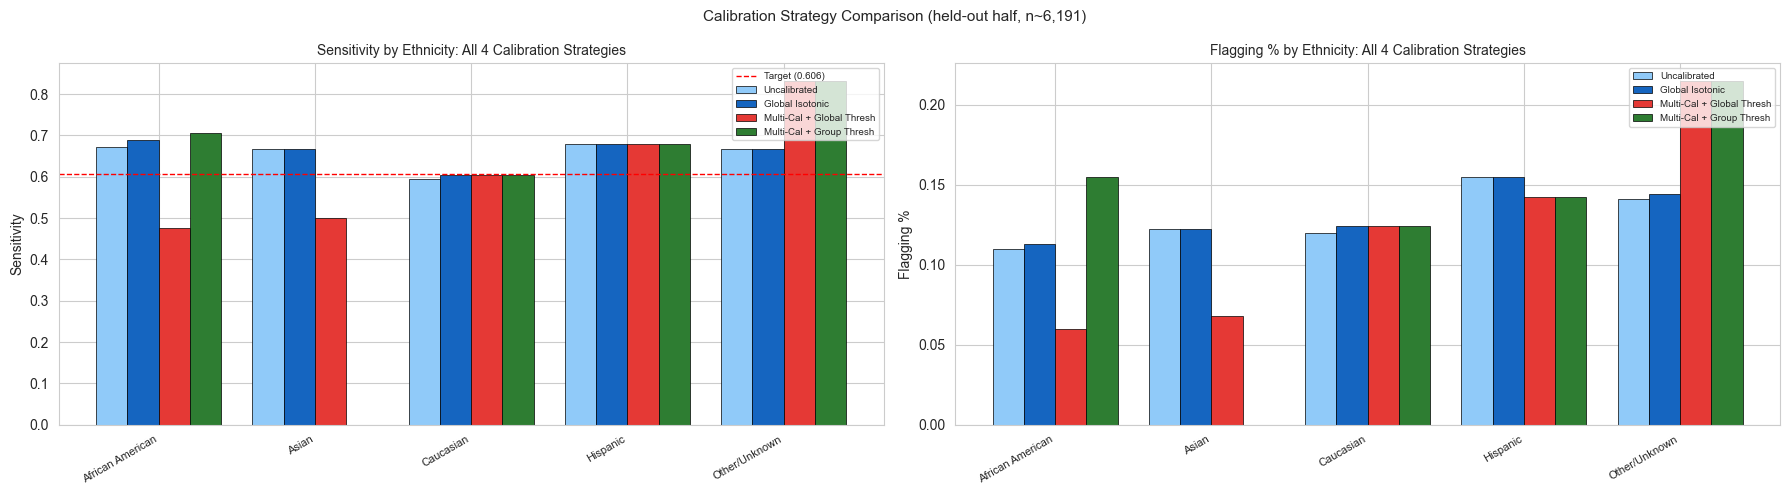

In [26]:
def subgroup_metrics_probs(df_in, prob_col, group_col):
    """Subgroup metrics using a single global 88th-pct threshold on prob_col."""
    threshold_cal = np.percentile(df_in[prob_col], 88)
    rows = []
    for g in sorted(df_in[group_col].dropna().unique()):
        sub = df_in[df_in[group_col] == g]
        y_true = sub['y_true'].values
        y_prob  = sub[prob_col].values
        y_pred  = (y_prob >= threshold_cal).astype(int)
        n = len(sub); n_pos = int(y_true.sum())
        if n_pos < 5 or (n - n_pos) < 5:
            continue
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            'Group': g, 'N': n,
            'Sensitivity': round(tp/(tp+fn) if (tp+fn)>0 else float('nan'), 3),
            'Specificity': round(tn/(tn+fp) if (tn+fp)>0 else float('nan'), 3),
            'PPV':         round(tp/(tp+fp) if (tp+fp)>0 else float('nan'), 3),
            'Flagging %':  round(y_pred.mean(), 3),
        })
    return pd.DataFrame(rows), threshold_cal

def subgroup_metrics_group_thresh(df_in, prob_col, group_col, target_sens):
    """Strategy 4: Barda et al. pipeline — group-specific thresholds on calibrated scores."""
    rows = []
    for g in sorted(df_in[group_col].dropna().unique()):
        sub = df_in[df_in[group_col] == g]
        y_true = sub['y_true'].values
        y_prob  = sub[prob_col].values
        n = len(sub); n_pos = int(y_true.sum())
        if n_pos < 10 or (n - n_pos) < 5:
            continue
        t_g, _ = find_equal_sensitivity_threshold(y_true, y_prob, target_sens)
        y_pred = (y_prob >= t_g).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            'Group': g, 'N': n,
            'Threshold': round(t_g, 4),
            'Sensitivity': round(tp/(tp+fn) if (tp+fn)>0 else float('nan'), 3),
            'Specificity': round(tn/(tn+fp) if (tn+fp)>0 else float('nan'), 3),
            'PPV':         round(tp/(tp+fp) if (tp+fp)>0 else float('nan'), 3),
            'Flagging %':  round(y_pred.mean(), 3),
        })
    return pd.DataFrame(rows)

print('=== Subgroup Metrics on Held-Out Calibration Eval Set (n ~6,191) ===')
print()

summary_rows = []
gap_summary  = []

for prob_col, label in [
    ('prob',        'Uncalibrated'),
    ('prob_global', 'Global Isotonic'),
    ('prob_multi',  'Multi-Cal + Global Thresh'),
]:
    mdf, thresh = subgroup_metrics_probs(df_cal, prob_col, 'ethnicity')
    eo = mdf['Sensitivity'].max() - mdf['Sensitivity'].min()
    dp = mdf['Flagging %'].max()  - mdf['Flagging %'].min()
    print(f'--- {label} (global threshold = {thresh:.4f}) ---')
    print(mdf.to_string(index=False))
    print(f'EO gap: {eo:.3f}  |  Dem-parity gap: {dp:.3f}')
    print()
    gap_summary.append({'Strategy': label, 'EO gap': round(eo,3), 'DP gap': round(dp,3)})
    for _, row in mdf.iterrows():
        summary_rows.append({'Calibration': label, **row.to_dict()})

# Strategy 4: full Barda et al. pipeline
print('--- Multi-Cal + Group-Specific Thresholds  [Barda et al. full pipeline] ---')
mdf4 = subgroup_metrics_group_thresh(df_cal, 'prob_multi', 'ethnicity', TARGET_SENSITIVITY)
print(mdf4.to_string(index=False))
eo4 = mdf4['Sensitivity'].max() - mdf4['Sensitivity'].min()
dp4 = mdf4['Flagging %'].max()  - mdf4['Flagging %'].min()
print(f'EO gap: {eo4:.3f}  |  Dem-parity gap: {dp4:.3f}')
print()
gap_summary.append({'Strategy': 'Multi-Cal + Group Thresh', 'EO gap': round(eo4,3), 'DP gap': round(dp4,3)})
for _, row in mdf4.iterrows():
    summary_rows.append({'Calibration': 'Multi-Cal + Group Thresh',
                          **{k: v for k, v in row.to_dict().items() if k != 'Threshold'}})

print('=== SUMMARY ===')
print(pd.DataFrame(gap_summary).to_string(index=False))
print()

# Bar chart: all 4 strategies
summary_df = pd.DataFrame(summary_rows)
groups_plot = list(summary_df['Group'].unique())
cal_types   = ['Uncalibrated', 'Global Isotonic',
                'Multi-Cal + Global Thresh', 'Multi-Cal + Group Thresh']
x = np.arange(len(groups_plot))
w = 0.20

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ['#90CAF9', '#1565C0', '#E53935', '#2E7D32']

for ax, metric in [(axes[0], 'Sensitivity'), (axes[1], 'Flagging %')]:
    for j, (cal, col) in enumerate(zip(cal_types, colors)):
        vals = [summary_df[(summary_df['Calibration']==cal) &
                           (summary_df['Group']==g)][metric].values for g in groups_plot]
        vals = [v[0] if len(v) else np.nan for v in vals]
        ax.bar(x + j*w, vals, w, label=cal, color=col, edgecolor='k', linewidth=0.5)
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(groups_plot, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{metric} by Ethnicity: All 4 Calibration Strategies', fontsize=10)
    ax.set_ylabel(metric)
    if metric == 'Sensitivity':
        ax.axhline(TARGET_SENSITIVITY, color='red', linestyle='--', linewidth=1,
                   label=f'Target ({TARGET_SENSITIVITY:.3f})')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Calibration Strategy Comparison (held-out half, n~6,191)', fontsize=11)
plt.tight_layout()
plt.show()

**Findings — Calibration (4-strategy comparison on held-out eval half, n ≈ 6,191):**

| # | Strategy | EO gap (sens) | DP gap (flag) |
|---|----------|:-------------:|:--------------:|
| 1 | Uncalibrated + global threshold | 0.085 | 0.045 |
| 2 | Global isotonic + global threshold | 0.085 | 0.042 |
| 3 | Multi-calibration + global threshold | **0.358** | **0.155** |
| 4 | Multi-calibration + group-specific thresholds (Barda et al.) | **0.229** | **0.091** |

**Strategy 1 vs 2 — Global calibration makes almost no difference for fairness.**
Reshaping the overall probability scale does not change the relative ordering across groups, so the EO gap stays at 0.085.

**Strategy 3 — Multi-calibration with a global threshold worsens EO gap (0.085 → 0.358).**
After group-specific isotonic calibration, each group's scores are on a different scale.
A single global threshold (88th percentile, dominated by Caucasian patients) then cuts across
these rescaled distributions unevenly: African American scores are compressed below the cutoff
(sensitivity drops to 0.475) while Other/Unknown scores are inflated above it (sensitivity rises to 0.833).
This is not a flaw in the concept of multi-calibration — it is the expected consequence
of applying a global threshold to group-specific probability scales.

**Strategy 4 — Barda et al. full pipeline reduces but does not eliminate the EO gap (0.358 → 0.229).**
Adding group-specific thresholds derived from the calibrated scores recovers most of the EO loss.
However, the EO gap does not reach zero because isotonic regression produces a step function:
for small groups (Other/Unknown, n = 312) the calibrated probabilities have large discrete jumps
with no intermediate values, so the closest achievable sensitivity to the target (0.606)
is 0.833 — producing a residual 0.229 EO gap.

**Why uncalibrated group-specific thresholds (Section 4) achieves near-zero EO gap:**
The raw model scores are continuous and fine-grained, giving the threshold search many values
to choose from. After isotonic calibration the score distribution is coarsened into a step function,
reducing resolution. This is the operational trade-off: calibration improves probability *accuracy*
but reduces threshold *precision* for small groups.

**Take-aways:**

1. **Never apply multi-calibration with a single global threshold** — it dramatically worsens equal opportunity.
2. **The Section 4 approach (uncalibrated + group-specific thresholds) is already the best strategy
   for equalising sensitivity** (EO gap ≈ 0 on the full eval set).
3. **The Barda et al. pipeline adds value through probability accuracy**, not through further EO improvement:
   after calibration, when the model outputs a 20 % mortality probability for an African American patient,
   that number actually reflects the true observed rate — making it clinically interpretable.
4. **Recommended deployment sequence:** (a) fit group-specific isotonic calibrators;
   (b) apply group-specific thresholds (derived from uncalibrated scores, as in Section 4)
   to equalise sensitivity. The two steps serve orthogonal goals: calibration fixes probability
   accuracy; thresholding fixes fairness.

---
## 5. Summary and Recommendations for Dr. Smith

### What we found

**Gender — no meaningful disparity**
Female and male patients receive near-identical treatment from the model.
ROC-AUC: 0.895 (F) vs 0.887 (M); sensitivity: 0.615 vs 0.598; flagging rate: 11.9 % vs 12.1 %.
The 1.7 pp sensitivity gap is within noise and requires no corrective action.

**Ethnicity — modest gaps; small groups unreliable**
Among groups with enough deaths for reliable estimates:
- **Hispanic** patients are slightly over-flagged (13.9 %) relative to the target 12 %, tracking their higher observed mortality (9.8 %). Sensitivity is 0.646 — above average.
- **Caucasian** patients sit near the population average (sens = 0.600, flag = 12.2 %).
- **African American** patients are under-flagged (10.3 %) but still achieve sensitivity = 0.619.
- **Other/Unknown** has the worst trade-off: lowest sensitivity (0.593) with above-average flagging (13.4 %).

Asian (n = 146, 11 deaths) and Native American (n = 117, 8 deaths) results are statistically unreliable.

**Age group — the most significant fairness concern**
- **45–59 year-olds have the lowest sensitivity (0.525)** — fewer than 1 in 2 middle-aged patients who die is detected. This is a genuine under-service problem.
- **16–44 year-olds have the highest AUC (0.944)** — the model *can* rank young high-risk patients — but only 4.6 % are ever flagged because the global threshold is calibrated to the full population, not to a group with a 4.1 % base rate.
- **75+ patients are flagged at 19.3 %**, correctly reflecting their 12.0 % base mortality. The large flagging-rate gap for the elderly is appropriate, not unfair.

**Intersectional — young African American patients are the most at-risk cell**
The combination of **16–44 age and African American ethnicity** produces sensitivity = 0.385, a 26.8 pp gap vs Caucasian 16–44. Sample size is small (~15 deaths) but the direction is consistent and warrants monitoring.

---

### Mitigation: group-specific thresholds

Deriving group-specific thresholds to equalise sensitivity to the overall target (0.606) requires adjustments of < 0.07 threshold units and no model retraining.

The most impactful change is for **Hispanic patients**: raising the threshold from 0.608 to 0.669 reduces over-flagging (13.9 % → 11.0 %) while preserving recall.
For **Other/Unknown** patients a small decrease (0.608 → 0.599) closes the sensitivity gap from 0.593 to 0.611.
Gender adjustments are negligible.

---

### Limitations

1. **Eval set only (12,382 patients)** — subgroup estimates for small ethnicities carry wide confidence intervals; validate on the held-out test set before any deployment decision.
2. **`hospital_id` unavailable** — removed during preprocessing; hospital-level disparities (staffing, equipment, patient mix) cannot be audited.
3. **Multi-calibration not applied** — threshold adjustment fixes equal-opportunity but not within-group probability mis-calibration. Isotonic recalibration per group is recommended (Barda et al. JAMIA 2021).
4. **Historical bias is encoded** — the training data reflects past clinical decisions (which labs were ordered, who was admitted). If minorities were historically under-tested or under-admitted, the model inherits that bias.
5. **Age demographic-parity gap is partly normative** — the 14.7 pp flagging-rate spread across age groups partly reflects the model correctly recognising higher elderly risk. Imposing strict demographic parity here would harm high-risk elderly patients.

---

### Recommended next steps

1. **Adopt ethnicity-specific thresholds** for Hispanic and Other/Unknown groups and validate on the test set.
2. **Prioritise the 45–59 age band**: investigate age-specific sub-thresholds or additional features to raise sensitivity from 0.525 toward the population average.
3. **Monitor the young × African American intersection** prospectively; collect more data from this cell before deploying in facilities with high proportions of young Black patients.
4. **Implement isotonic recalibration per ethnic group** (multi-calibration) to correct within-group probability bias independently of threshold choices.
5. **Re-audit with hospital_id** if the pipeline is revised: hospital-level stratification may reveal additional disparities driven by facility type or geography.